In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"
df = pd.read_csv(CATALOG)

print(f"Total catalog objects: {len(df):,}")
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")
centrals = resolved[
    resolved["IsSatellite"] == False
].copy()

satellites = resolved[
    (resolved["IsSatellite"] == True) &
    resolved[["x", "y", "z"]].notna().all(axis=1)
].copy()

nearest_distances = []

for _, central in centrals.iterrows():

    sats = satellites[
        satellites["GroupID"] == central["GroupID"]
    ]

    if len(sats) == 0:
        nearest_distances.append(np.nan)
        continue

    box_size = 205000.0  # TNG300-1 box size in ckpc/h

    dx = np.abs(sats["x"].to_numpy() - central["x"])
    dy = np.abs(sats["y"].to_numpy() - central["y"])
    dz = np.abs(sats["z"].to_numpy() - central["z"])

    dx = np.minimum(dx, box_size - dx)
    dy = np.minimum(dy, box_size - dy)
    dz = np.minimum(dz, box_size - dz)

    distances = np.sqrt(dx**2 + dy**2 + dz**2)


    nearest_distances.append(np.min(distances))

centrals["NearestSatelliteDistance"] = nearest_distances
dmdgs = centrals[
    centrals["f_DM"] < 0.5
].copy()
dmdgs_non_extreme = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"Centrals: {len(centrals):,}")
print(f"DMDGS (total): {len(dmdgs):,}")
print(f"DMDGS (non-tidal stripping): {len(dmdgs_non_extreme):,}")
print(f"DMDGS Fraction: {(len(dmdgs_non_extreme) / len(centrals)):,}")


Total catalog objects: 13,922,457
Resolved galaxies: 154,638
Centrals: 93,039
DMDGS (total): 96
DMDGS (non-tidal stripping): 96
DMDGS Fraction: 0.0010318253635572179


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"

df = pd.read_csv(CATALOG)
print(f"Total Catalog Objects: {len(df):,}")
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")

resolved["M_star_Msun"] = (
    resolved["M_star"] * 1e10 / 0.6774
)

mass_selected = resolved[
    (resolved["M_star_Msun"] > 1e9) &
    (resolved["M_star_Msun"] < 1e10)
].copy()
satellites = mass_selected[
    mass_selected["IsSatellite"] == True
].copy()
satellites["Host_M200c_Msun"] = (
    satellites["Host_M200c"] * 1e10 / 0.6774
)
group_selected = satellites[
    satellites["Host_M200c_Msun"] > 1e13
].copy()
dmdgs = group_selected[
    group_selected["f_DM"] < 0.5
].copy()
dmdgs_non_extreme_satellites = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"DMDGS (non-tidal stripping): {len(dmdgs_non_extreme_satellites):,}")

Total Catalog Objects: 13,922,457
Resolved galaxies: 154,638
DMDGS (non-tidal stripping): 400


In [ ]:
plt.boxplot(dmdgs_non_extreme["R_half_star"], vert=False, showfliers=False, showmeans=True)
plt.title("DMDG Centrals $R_{\\text{half, \\star}}$")
plt.ylabel("$R_{\\text{half, \\star}}$")
plt.show()
print(f"DMDGs Central Median: {dmdgs_non_extreme["R_half_star"].median()}")
print(f"DMDGs Central Mean: {dmdgs_non_extreme["R_half_star"].mean()}")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1824747543.py, line 5)

In [ ]:
plt.boxplot(centrals["R_half_star"], vert=False, showfliers=False, showmeans=True)
plt.title("Centrals $R_{\\text{half, \\star}}$")
plt.ylabel("$R_{\\text{half, \\star}}$")
plt.show()
print(f"Central Median: {centrals["R_half_star"].median()}")
print(f"Central Mean: {centrals["R_half_star"].mean()}")

C:\Users\adaly\AppData\Local\Temp\ipykernel_15624\3516399252.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(dmdgs_non_extreme_satellites["R_half_star"], vert=False, showfliers=False, showmeans=True)


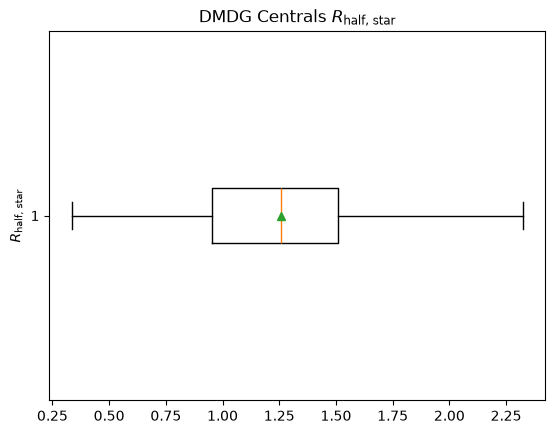

In [ ]:
plt.boxplot(dmdgs_non_extreme_satellites["R_half_star"], vert=False, showfliers=False, showmeans=True)
plt.title("DMDG Satellites (Literature) $R_{\\text{half, \\star}}$")
plt.ylabel("$R_{\\text{half, \\star}}$")
plt.show()
print(f"DMDG Satellites Median: {dmdgs_non_extreme_satellites["R_half_star"].median()}")
print(f"DMDG Satellites Mean: {dmdgs_non_extreme_satellites["R_half_star"].mean()}")

In [ ]:
plt.boxplot(group_selected["R_half_star"], vert=False, showfliers=False, showmeans=True)
plt.title("Satellites (Literature) $R_{\\text{half, \\star}}$")
plt.ylabel("$R_{\\text{half, \\star}}$")
plt.show()
print(f"Satellites Median: {group_selected["R_half_star"].median()}")
print(f"Satellites Mean: {group_selected["R_half_star"].mean()}")